# 5 分钟上手 StatsPAI（Stata 用户版）

这份教程写给**会用 Stata、想试试 Python** 的读者。每一节都是同一个套路。

1. 先给出你熟悉的 Stata 命令和 Stata 的真实输出
2. 再给出一行等价的 StatsPAI 代码，直接运行
3. 对比两边的数字

全程只需要 `import statspai as sp` 一次。数据都随包自带，不用联网，也**不需要安装 Stata**。文中的 Stata 输出是我们事先用 Stata 18 在同一份数据上跑出来贴进来的，方便你对照。

| 第几节 | 方法 | Stata 命令 | StatsPAI 函数 |
| --- | --- | --- | --- |
| 1 | OLS + 稳健标准误 | `regress ..., r` | `sp.regress` |
| 2 | 高维固定效应 + 聚类 | `reghdfe` | `sp.hdfe_ols` |
| 3 | 工具变量 2SLS | `ivregress 2sls` | `sp.ivreg` |
| 4 | 回归表格导出 | `esttab` / `outreg2` | `sp.regtable` |
| 5 | 交错 DID | `csdid` | `sp.callaway_santanna` |
| 6 | 断点回归 | `rdrobust` | `sp.rdrobust` |
| 7 | 直接粘贴 Stata 命令 | | `sp.from_stata` |

## 0. 安装与导入

终端里执行一次 `pip install "statspai[plotting]"` 即可（`[plotting]` 会顺带装上画图用的 matplotlib）。之后所有功能都从 `sp.` 进入，相当于 Stata 里不用再 `ssc install` 各种外部命令。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import pandas as pd
import statspai as sp

print("StatsPAI 版本:", sp.__version__)

# 三份随包自带的教学数据，对应 Stata 里的 use xxx.dta
card = sp.datasets.card_1995()          # Card (1995) 教育回报率，真实 NLSYM 数据
mpdta = sp.datasets.mpdta()             # 最低工资与青少年就业，县 × 年面板（仿 R did 包 mpdta 的模拟数据）
senate = sp.datasets.lee_2008_senate()  # 美国参议院选举，断点回归（R rdrobust 包自带的数据）

card.head()  # 相当于 Stata 的 list in 1/5

StatsPAI 版本: 1.34.2


,lwage,educ,exper,expersq,black,south,smsa,nearc4,nearc2
0,6.306275,7,16,256,1,0,1,0,0
1,6.175867,12,9,81,0,0,1,0,0
2,6.580639,12,16,256,0,0,1,0,0
3,5.521461,11,10,100,0,0,1,1,1
4,6.591674,12,16,256,0,0,1,1,1


> **想在自己电脑上用 Stata 复核？** 把数据导出成 CSV，再在 Stata 里 `import delimited` 就是同一份数据。
>
> ```python
> card.to_csv("card.csv", index=False)
> ```

## 1. OLS 回归 + 稳健标准误

**Stata**

```stata
reg lwage educ exper expersq black south smsa, r
```

```text
Linear regression                               Number of obs     =      3,010
                                                R-squared         =     0.2905
------------------------------------------------------------------------------
             |               Robust
       lwage | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        educ |    .074009    .003642    20.32   0.000     .0668679    .0811501
       exper |   .0835958   .0067326    12.42   0.000     .0703948    .0967969
     expersq |  -.0022409   .0003181    -7.04   0.000    -.0028646   -.0016171
       black |  -.1896315   .0174324   -10.88   0.000    -.2238123   -.1554508
       south |  -.1248615   .0153508    -8.13   0.000    -.1549606   -.0947625
        smsa |    .161423   .0151751    10.64   0.000     .1316683    .1911776
       _cons |   4.733664   .0701577    67.47   0.000     4.596102    4.871226
------------------------------------------------------------------------------
```

**StatsPAI** 用公式写法，`y ~ x1 + x2`。Stata 的 `, r` 对应 `robust="hc1"`。

In [2]:
# 被解释变量 ~ 解释变量，用 + 连接；常数项自动加入
ols = sp.regress(
    "lwage ~ educ + exper + expersq + black + south + smsa",
    data=card,
    robust="hc1",  # 等价于 Stata 的 , robust
)
print(ols.summary())

Model: OLS
Method: Least Squares
Dependent Variable: lwage
           Coefficient  Std. Error  t-statistic  P>|t|  [0.025  0.975]
Intercept       4.7337      0.0702      67.4718 0.0000  4.5961  4.8712
educ            0.0740      0.0036      20.3208 0.0000  0.0669  0.0812
exper           0.0836      0.0067      12.4165 0.0000  0.0704  0.0968
expersq        -0.0022      0.0003      -7.0443 0.0000 -0.0029 -0.0016
black          -0.1896      0.0174     -10.8781 0.0000 -0.2238 -0.1555
south          -0.1249      0.0154      -8.1339 0.0000 -0.1550 -0.0948
smsa            0.1614      0.0152      10.6374 0.0000  0.1317  0.1912

Model Diagnostics:
--------------------
R-squared           : 0.2905
Adj. R-squared      : 0.2891
F-statistic         : 204.9318
Prob (F-statistic)  : 0.0000
Log-Likelihood      : -1308.7016
AIC                 : -5910.6068
BIC                 : -5868.5390


In [3]:
# 结果是一个对象，系数和标准误可以直接取出来（相当于 Stata 的 _b[educ] 和 _se[educ]）
print("educ 系数  :", round(ols.params["educ"], 8))
print("educ 标准误:", round(ols.std_errors["educ"], 8))
print("Stata 给出 : 0.07400899 / 0.00364203")

educ 系数  : 0.07400899
educ 标准误: 0.00364203
Stata 给出 : 0.07400899 / 0.00364203


## 2. 高维固定效应 + 聚类标准误

**Stata**

```stata
reghdfe lemp treat, absorb(countyreal year) vce(cluster countyreal)
```

```text
HDFE Linear regression                            Number of obs   =      2,500
                                                  R-squared       =     0.8294
                                                  Within R-sq.    =     0.0205
                           (Std. err. adjusted for 500 clusters in countyreal)
------------------------------------------------------------------------------
        lemp | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
       treat |  -.0375051   .0057836    -6.48   0.000    -.0488682   -.0261419
------------------------------------------------------------------------------
```

**StatsPAI** 把固定效应写在竖线 `|` 后面，和 R 的 `fixest` 语法一致。`sp.hdfe_ols` 是自带的高维固定效应引擎，不依赖任何外部包。

In [4]:
# 竖线左边是回归方程，右边是要吸收的固定效应（对应 absorb()）
fe = sp.hdfe_ols(
    "lemp ~ treat | countyreal + year",
    data=mpdta,
    cluster="countyreal",  # 对应 vce(cluster countyreal)
)
print(fe.summary())

FEOLS (reghdfe-style)  |  lemp ~ treat | countyreal + year
Obs: 2,500   Singletons dropped: 0
Absorbed FE: groups=[500, 5]   dof_fe=504   df_resid=1995
R² = 0.8294   Adj. R² = 0.7863   R² (within) = 0.0205   Adj. R² (within) = 0.0200
SE type: cluster   p-values / CIs: t(499)
Cluster info: {'cluster': ['countyreal'], 'n_clusters': [500], 'dof_fe_cluster': 5, 'nested_fe': ['countyreal']}
------------------------------------------------------------
Variable                Estimate     Std.Err       t         p
------------------------------------------------------------
treat                    -0.0375      0.0058   -6.48    0.0000  ***


## 3. 工具变量（2SLS）

用「家附近有没有四年制大学」(`nearc4`) 作为教育年限 (`educ`) 的工具变量。

**Stata**

```stata
ivregress 2sls lwage exper expersq black south smsa (educ = nearc4), r small
```

```text
Instrumental variables 2SLS regression            Number of obs   =      3,010
------------------------------------------------------------------------------
             |               Robust
       lwage | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        educ |   .1322888   .0485779     2.72   0.007     .0370396    .2275381
       exper |    .107498   .0211375     5.09   0.000     .0660525    .1489434
     expersq |  -.0022841   .0003467    -6.59   0.000    -.0029639   -.0016042
       black |  -.1308019   .0515112    -2.54   0.011    -.2318027   -.0298011
       south |  -.1049005   .0229264    -4.58   0.000    -.1498535   -.0599475
        smsa |   .1313237    .029803     4.41   0.000     .0728872    .1897601
       _cons |   3.752781   .8177012     4.59   0.000      2.14947    5.356092
------------------------------------------------------------------------------
```

**StatsPAI** 的写法和 Stata 几乎一样，把 `(educ = nearc4)` 换成 `(educ ~ nearc4)`。

In [5]:
# 括号里是 (内生变量 ~ 工具变量)，括号外是外生控制变量
iv = sp.ivreg(
    "lwage ~ (educ ~ nearc4) + exper + expersq + black + south + smsa",
    data=card,
    robust="hc1",
)
print(iv.summary())

Model: IV-2SLS
Method: Two-Stage Least Squares
Dependent Variable: lwage
           Coefficient  Std. Error  t-statistic  P>|t|  [0.025  0.975]
Intercept       3.7528      0.8177       4.5894 0.0000  2.1495  5.3561
exper           0.1075      0.0211       5.0857 0.0000  0.0661  0.1489
expersq        -0.0023      0.0003      -6.5872 0.0000 -0.0030 -0.0016
black          -0.1308      0.0515      -2.5393 0.0112 -0.2318 -0.0298
south          -0.1049      0.0229      -4.5755 0.0000 -0.1499 -0.0599
smsa            0.1313      0.0298       4.4064 0.0000  0.0729  0.1898
educ            0.1323      0.0486       2.7232 0.0065  0.0370  0.2275

Model Diagnostics:
--------------------
R-squared                       : 0.2252
N instruments                   : 1
N endogenous                    : 1
First-stage F (educ)            : 17.5133
First-stage F p-value (educ)    : 0.0000
First-stage F, non-robust (educ): 16.7176
Partial R² (educ)               : 0.0055
Hausman F-stat                  : 1.539

两点值得留意。

- 标准误对应的是 Stata 加了 `small` 选项的结果（小样本自由度修正、t 分布）。Stata 不加 `small` 时 `educ` 的标准误是 0.0485213，差别来自自由度除数，系数完全相同。
- 第一阶段 F 统计量、Hausman 检验已经自动附在结果下面，不需要另外敲 `estat firststage` 和 `estat endogenous`。

## 4. 把多个模型放进一张表

**Stata**

```stata
eststo m1: reg lwage educ exper expersq black south smsa, r
eststo m2: ivregress 2sls lwage exper expersq black south smsa (educ = nearc4), r small
esttab m1 m2, se star(* 0.1 ** 0.05 *** 0.01)
```

**StatsPAI** 一行搞定，模型对象直接传进去。

In [6]:
# 相当于 esttab m1 m2；括号里是标准误
table = sp.regtable(ols, iv, model_labels=["OLS", "2SLS"])
table

,OLS,2SLS
Intercept,4.734***,3.753***
,(0.070),(0.818)
educ,0.0740***,0.1323***
,(0.0036),(0.0486)
exper,0.0836***,0.1075***
,(0.0067),(0.0211)
expersq,-0.00224***,-0.00228***
,(0.00032),(0.00035)
black,-0.190***,-0.131**
,(0.017),(0.052)


导出也是一行（对应 `esttab using` / `outreg2`），按文件后缀自动选择格式。

```python
sp.regtable(ols, iv, filename="table1.docx")   # Word
sp.regtable(ols, iv, filename="table1.xlsx")   # Excel
sp.regtable(ols, iv, filename="table1.tex")    # LaTeX
```

## 5. 交错 DID（Callaway & Sant'Anna）

各县在 2004、2006、2007 年先后提高最低工资，处理时点不一致，传统 TWFE 会有偏。Stata 里要装 `csdid` 和 `drdid` 两个外部命令。

**Stata**

```stata
csdid lemp, ivar(countyreal) time(year) gvar(first_treat) method(dripw)
estat simple
estat event
```

```text
Average Treatment Effect on Treated
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
         ATT |  -.0329765   .0077645    -4.25   0.000    -.0481948   -.0177583
------------------------------------------------------------------------------

Event Study:Dynamic effects
------------------------------------------------------------------------------
         Tp0 |  -.0338372   .0074583    -4.54   0.000    -.0484553   -.0192192
         Tp1 |  -.0280312   .0088921    -3.15   0.002    -.0454594    -.010603
         Tp2 |  -.0455279   .0147806    -3.08   0.002    -.0744973   -.0165585
         Tp3 |  -.0277339   .0143663    -1.93   0.054    -.0558914    .0004236
------------------------------------------------------------------------------
```

In [7]:
# 第一步：估计每个「组 × 时期」的 ATT，对应 csdid 主命令
cs = sp.callaway_santanna(
    data=mpdta,
    y="lemp",          # 结果变量
    g="first_treat",   # 首次受处理的年份，对应 gvar()；从未处理为 0
    t="year",          # 时间变量，对应 time()
    i="countyreal",    # 个体变量，对应 ivar()
)

# 第二步：汇总成一个总体 ATT，对应 estat simple
att = sp.aggte(cs, type="simple")
print("总体 ATT :", round(att.estimate, 7))
print("标准误   :", round(att.se, 7))
print("Stata 给出: -0.0329765 / 0.0077645")

总体 ATT : -0.0329765
标准误   : 0.0077645
Stata 给出: -0.0329765 / 0.0077645


In [8]:
# 事件研究（动态效应），对应 estat event
es = sp.aggte(cs, type="dynamic")
es.detail  # 每个相对时期一行

,relative_time,att,se,ci_lower,ci_upper,pvalue
0,-4,-0.004903,0.014537,-0.033394,0.023588,0.735897
1,-3,0.009883,0.010867,-0.011416,0.031183,0.363105
2,-2,0.007555,0.008713,-0.009522,0.024633,0.385876
3,0,-0.033837,0.007458,-0.048455,-0.019219,0.000006
4,1,-0.028031,0.008892,-0.045459,-0.010603,0.001620
5,2,-0.045528,0.014781,-0.074497,-0.016559,0.002068
6,3,-0.027734,0.014366,-0.055891,0.000424,0.053548


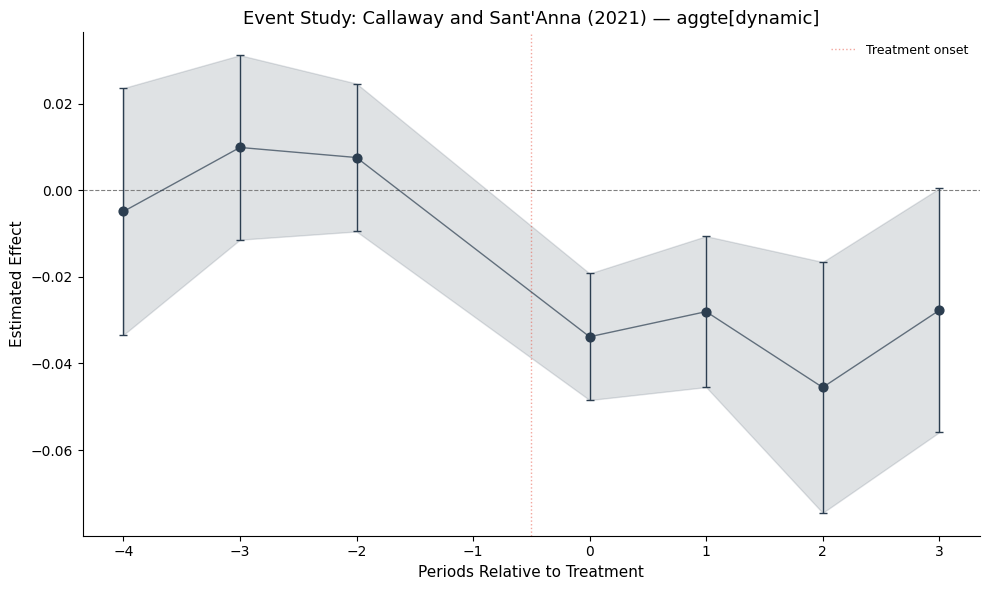

In [9]:
# 一行出图，对应 Stata 的 csdid_plot
es.plot();

处理后各期（e = 0 到 3）和 Stata 完全一致。处理前各期的数字和 Stata 默认输出不同，这**不是误差**，而是基期约定不同。StatsPAI 默认用统一基期（处理前一期，图上 e = -1 归零），`csdid` 默认用逐期滚动基期。想复现 Stata 的处理前系数，加一个参数即可。

```python
cs_varying = sp.callaway_santanna(..., base_period="varying")
```

## 6. 断点回归（RD）

美国参议院选举中，以微弱优势胜选的政党在下一次选举里得票率会高多少？

**Stata**

```stata
rdrobust y x, c(0) all
```

```text
Sharp RD estimates using local polynomial regression.

      Cutoff c = 0 | Left of c  Right of c            Number of obs =      1297
-------------------+----------------------            BW type       =     mserd
     Number of obs |       595         702            Kernel        = Triangular
Eff. Number of obs |       360         323            VCE method    =        NN
       BW est. (h) |    17.754      17.754
       BW bias (b) |    28.028      28.028

            Method |   Coef.    Std. Err.    z     P>|z|    [95% Conf. Interval]
-------------------+------------------------------------------------------------
      Conventional |  7.4141     1.4587   5.0826   0.000     4.5551      10.2732
            Robust |  7.5065     1.7413   4.3110   0.000     4.0937      10.9193
```

In [10]:
# y 是结果变量，x 是驱动变量，c 是断点；带宽自动选择（mserd），和 Stata 默认一致
rd = sp.rdrobust(data=senate, y="y", x="x", c=0)
print(rd.summary())

  Sharp RD Estimation

  RD Effect:       7.51 ***
  Std. Error:  (1.74)
  [95% CI]:    [4.09,  10.92]
  P-value:     <0.001

------------------------------------------------------------------------------
  Inference
------------------------------------------------------------------------------
      method  estimate     se      z  pvalue  ci_lower  ci_upper
Conventional    7.4141 1.4587 5.0826  0.0000    4.5551   10.2732
      Robust    7.5065 1.7413 4.3110  0.0000    4.0937   10.9193

------------------------------------------------------------------------------
  Observations:    1,297
  Rd Type:    Sharp
  Deriv:    0
  Donut:    0
  Polynomial P:    1
  Polynomial Q:    2
  Kernel:    triangular
  Bandwidth H:    17.7544
  Bandwidth B:    28.0281
  Bwselect:    mserd
  Cutoff:    0
  N Left:    595
  N Right:    702
  N Effective Left:    360
  N Effective Right:    323
  N Unique Running:    1260
  Vce:    nn
  Weighted:    False
  (2 solver/diagnostic entries hidden; see .model_

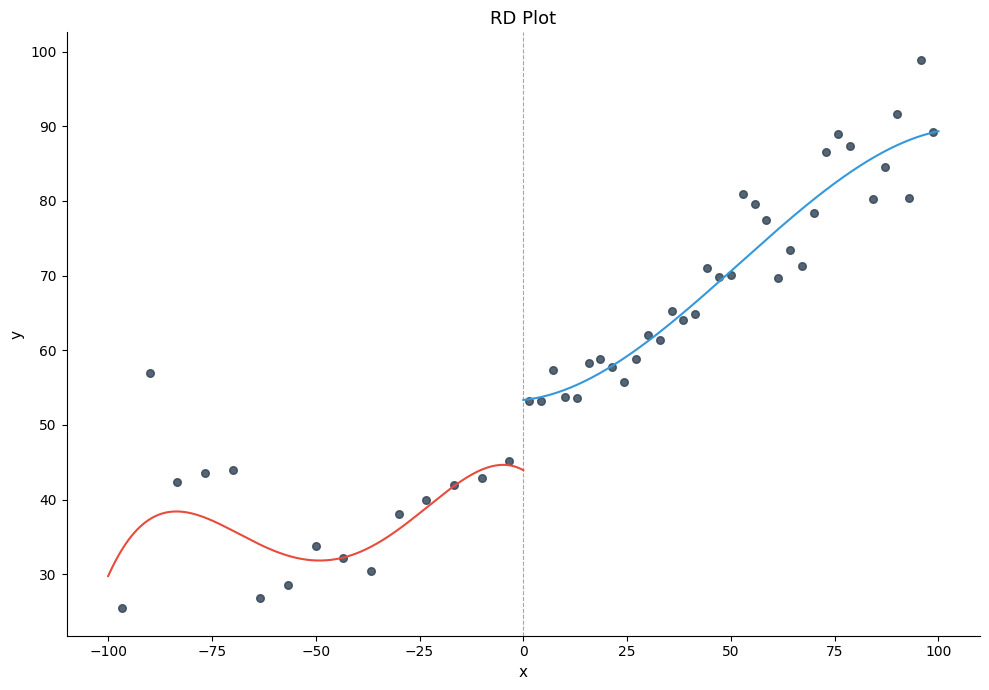

In [11]:
# 断点图，对应 Stata 的 rdplot y x
sp.rdplot(data=senate, y="y", x="x", c=0, hide_ci=True);

## 7. 懒人通道：直接粘贴 Stata 命令

还不熟悉 Python 语法也没关系。`sp.from_stata` 会把一行 Stata 命令翻译成 StatsPAI 代码，告诉你该怎么写。

In [12]:
# 把你平时写的 Stata 命令原样放进来
r = sp.from_stata("reghdfe lemp treat, absorb(countyreal year) vce(cluster countyreal)")
print("对应的 Python 代码:")
print(r["python_code"])

对应的 Python 代码:
sp.hdfe_ols('lemp ~ treat | countyreal + year', data=df, cluster='countyreal')


In [13]:
r = sp.from_stata("ivregress 2sls lwage exper expersq black south smsa (educ = nearc4), r")
print(r["python_code"])
print("未能翻译的选项:", r["untranslated_options"])  # 空列表表示全部翻译成功
print("翻译器的提醒:", r["notes"][0])

sp.ivreg('lwage ~ exper + expersq + black + south + smsa + (educ ~ nearc4)', data=df, method='2sls', robust='hc1')
未能翻译的选项: []
翻译器的提醒: sp.ivreg standard errors follow `ivregress ..., small` (N-K divisor; cluster SEs add (N-1)/(N-K)). Without `small`, Stata reports large-sample SEs -- vce(robust) equals sp.ivreg robust='hc0' -- so SEs differ by about sqrt(N/(N-K)).


几点说明。

- 第一条翻译出来的代码和第 2 节手写的完全一样。
- 第二条里翻译器主动提醒了第 3 节讲过的 `small` 自由度差异。两边默认约定不一样的地方，它会写出来。
- 遇到看不懂的选项时会**明确列出来**，不会悄悄丢掉。

## 对照总表：Stata 18、StatsPAI、statsmodels、linearmodels

下面把前面六节的核心数字放在一起，并加上 Python 里两个常用的计量包作参照。Stata 一列是真实运行结果，其余三列由本 notebook 现场算出。`statsmodels` 和 `linearmodels` 都是 StatsPAI 的依赖，装 StatsPAI 时已经一并装好。

In [14]:
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS
from linearmodels.panel import PanelOLS

# ---- statsmodels ----
# OLS + HC1 稳健标准误
sm_ols = smf.ols("lwage ~ educ + exper + expersq + black + south + smsa", data=card).fit(cov_type="HC1")
# 没有吸收固定效应的命令，只能把县和年份写成虚拟变量（LSDV），再按县聚类
sm_fe = smf.ols("lemp ~ treat + C(countyreal) + C(year)", data=mpdta).fit(
    cov_type="cluster", cov_kwds={"groups": mpdta["countyreal"]}
)

# ---- linearmodels ----
# 不写内生变量时，IV2SLS 就是 OLS；debiased=True 对应小样本自由度修正
lm_ols = IV2SLS.from_formula(
    "lwage ~ 1 + educ + exper + expersq + black + south + smsa", data=card
).fit(cov_type="robust", debiased=True)
# 工具变量写在方括号里
lm_iv = IV2SLS.from_formula(
    "lwage ~ 1 + exper + expersq + black + south + smsa + [educ ~ nearc4]", data=card
).fit(cov_type="robust", debiased=True)
# 面板固定效应要先把 (个体, 时间) 设成索引
lm_fe = PanelOLS.from_formula(
    "lemp ~ treat + EntityEffects + TimeEffects", data=mpdta.set_index(["countyreal", "year"])
).fit(cov_type="clustered", cluster_entity=True)

NA = float("nan")  # 该包没有对应的估计量
rows = [
    # (方法, 统计量, Stata 18, StatsPAI, statsmodels, linearmodels)
    ("OLS (reg, r)",        "educ 系数",   0.07400899, ols.params["educ"], sm_ols.params["educ"], lm_ols.params["educ"]),
    ("OLS (reg, r)",        "educ 标准误", 0.00364203, ols.std_errors["educ"], sm_ols.bse["educ"], lm_ols.std_errors["educ"]),
    ("固定效应 (reghdfe)",   "treat 系数",  -0.03750510, fe.params["treat"], sm_fe.params["treat"], lm_fe.params["treat"]),
    ("固定效应 (reghdfe)",   "treat 标准误", 0.00578357, fe.std_errors["treat"], sm_fe.bse["treat"], lm_fe.std_errors["treat"]),
    ("2SLS (ivregress)",    "educ 系数",   0.13228884, iv.params["educ"], NA, lm_iv.params["educ"]),
    ("2SLS (ivregress)",    "educ 标准误", 0.04857786, iv.std_errors["educ"], NA, lm_iv.std_errors["educ"]),
    ("交错 DID (csdid)",     "总体 ATT",    -0.0329765, att.estimate, NA, NA),
    ("交错 DID (csdid)",     "ATT 标准误",  0.0077645, att.se, NA, NA),
    ("断点回归 (rdrobust)",  "稳健估计",    7.506502, rd.estimate, NA, NA),
    ("断点回归 (rdrobust)",  "稳健标准误",  1.741258, rd.se, NA, NA),
]
cols = ["方法", "统计量", "Stata 18", "StatsPAI", "statsmodels", "linearmodels"]
compare = pd.DataFrame(rows, columns=cols)
compare["StatsPAI 与 Stata 差值"] = (compare["StatsPAI"] - compare["Stata 18"]).abs()
fmt = {c: "{:.7f}" for c in cols[2:]}
fmt["StatsPAI 与 Stata 差值"] = "{:.1e}"
compare.style.format(fmt, na_rep="—")

,方法,统计量,Stata 18,StatsPAI,statsmodels,linearmodels,StatsPAI 与 Stata 差值
0,"OLS (reg, r)",educ 系数,0.0740090,0.0740090,0.0740090,0.0740090,4.2e-09
1,"OLS (reg, r)",educ 标准误,0.0036420,0.0036420,0.0036420,0.0036420,3.5e-09
2,固定效应 (reghdfe),treat 系数,-0.0375051,-0.0375051,-0.0375051,-0.0375051,2.3e-08
3,固定效应 (reghdfe),treat 标准误,0.0057836,0.0057836,0.0064666,0.0064614,4.8e-10
4,2SLS (ivregress),educ 系数,0.1322888,0.1322888,—,0.1322888,1.9e-11
5,2SLS (ivregress),educ 标准误,0.0485779,0.0485779,—,0.0485779,3.0e-10
6,交错 DID (csdid),总体 ATT,-0.0329765,-0.0329765,—,—,1.4e-08
7,交错 DID (csdid),ATT 标准误,0.0077645,0.0077645,—,—,4.3e-08
8,断点回归 (rdrobust),稳健估计,7.5065020,7.5065025,—,—,4.8e-07
9,断点回归 (rdrobust),稳健标准误,1.7412580,1.7412584,—,—,4.1e-07


怎么读这张表。

- **StatsPAI 与 Stata** 十个数字的差值都在 Stata 屏幕显示的最后一位以内，差异只来自 Stata 输出时的四舍五入。
- **OLS 和 2SLS** 四个软件给出同样的系数和标准误。
- **固定效应的标准误** 是唯一对不上的一行，系数相同，`statsmodels` (0.00647) 和 `linearmodels` (0.00646) 的聚类标准误比 Stata 的 0.00578 大约 12%。这不是谁算错了，而是自由度约定不同。500 个县固定效应嵌套在聚类变量里，`reghdfe` 做小样本修正时不把它们计入参数个数，另外两个包会计入。StatsPAI 默认跟随 `reghdfe`。
- **"—"** 表示该包没有对应的估计量。`statsmodels` 没有带稳健标准误的 2SLS，两个包都没有 Callaway & Sant'Anna 交错 DID 和 `rdrobust` 式的断点回归，需要另找专门的包。StatsPAI 里这些都在同一个 `sp.` 下面。

## 速查表

| 想做的事 | Stata | StatsPAI |
| --- | --- | --- |
| 读数据 | `use data.dta` | `df = pd.read_stata("data.dta")` |
| OLS | `reg y x1 x2, r` | `sp.regress("y ~ x1 + x2", data=df, robust="hc1")` |
| 聚类标准误 | `reg y x, cluster(id)` | `sp.regress("y ~ x", data=df, cluster="id")` |
| 固定效应 | `reghdfe y x, absorb(id year)` | `sp.hdfe_ols("y ~ x \| id + year", data=df)` |
| 工具变量 | `ivregress 2sls y w (x = z)` | `sp.ivreg("y ~ (x ~ z) + w", data=df)` |
| 交错 DID | `csdid` + `estat simple` | `sp.callaway_santanna` + `sp.aggte` |
| 断点回归 | `rdrobust y x` | `sp.rdrobust(data=df, y="y", x="x")` |
| 回归表格 | `esttab` / `outreg2` | `sp.regtable(m1, m2)` |
| 查帮助 | `help regress` | `sp.help("regress")` |
| 找函数 | `search did` | `sp.list_functions()` |

## 接下来

- `sp.help("did")` 查看任意函数的说明和示例
- `sp.list_functions()` 列出全部可用函数
- 同目录上一级的 `examples/*.py` 有合成控制、DML、g-methods 等更多示例
- 完整文档见 <https://github.com/brycewang-stanford/StatsPAI>